In [16]:
# Example: Recommend books for a user using SVD
user_id = 14
user_rows = ratings[ratings['User-ID'] == user_id]
if not user_rows.empty:
    user_idx = user_rows['user_idx'].iloc[0]
    all_books = ratings['book_idx'].unique()
    rated_books = ratings[ratings['user_idx'] == user_idx]['book_idx'].values
    books_to_predict = [book for book in all_books if book not in rated_books]
    predictions = [(book, svd_model.predict(user_idx, book).est) for book in books_to_predict]
    top_books = sorted(predictions, key=lambda x: x[1], reverse=True)[:10]
    print('Top recommended books for user', user_id, ':', top_books)

    # Map book_idx to ISBN
    book_idx_to_isbn = dict(zip(ratings['book_idx'], ratings['ISBN']))
    top_book_indices = [book_idx for book_idx, _ in top_books]
    top_isbns = [book_idx_to_isbn[idx] for idx in top_book_indices]

    # Get book titles from books DataFrame
    top_titles = books[books['ISBN'].isin(top_isbns)][['ISBN', 'Book-Title']]
    top_titles_ordered = pd.DataFrame({'ISBN': top_isbns}).merge(top_titles, on='ISBN', how='left')
    print('Top recommended book titles for user', user_id, ':')
    print(top_titles_ordered)
else:
    print(f"User-ID {user_id} not found in ratings data.")

# NCF and GNN: Add recommendation code as needed

Top recommended books for user 14 : [(55465, 8.906940489458414), (128226, 8.893554804032709), (55464, 8.7776476444743), (81097, 8.776451399504127), (5418, 8.774551441996854), (84506, 8.717885425687443), (141363, 8.706533319754476), (55462, 8.690080782110572), (169237, 8.689974411629395), (144887, 8.68406594455645)]
Top recommended book titles for user 14 :
         ISBN                                         Book-Title
0   345339738  The Return of the King (The Lord of the Rings,...
1   743454529       My Sister's Keeper : A Novel (Picoult, Jodi)
2   345339711     The Two Towers (The Lord of the Rings, Part 2)
3   439425220  Harry Potter and the Chamber of Secrets Postca...
4  055321313X  Anne of Green Gables (Anne of Green Gables Nov...
5   446310786                              To Kill a Mockingbird
6   812550706      Ender's Game (Ender Wiggins Saga (Paperback))
7   345339681  The Hobbit : The Enchanting Prelude to The Lor...
8  950491036X                               La Sombra de

## 9. Generate Book Recommendations
Use the best model to recommend books for sample users.

In [11]:
# SVD Grid Search
param_grid = {'n_epochs': [10, 20], 'lr_all': [0.002, 0.005], 'reg_all': [0.2, 0.4]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data_surprise)
print('Best SVD RMSE:', gs.best_score['rmse'])
print('Best SVD Params:', gs.best_params['rmse'])

# NCF and GNN: Add hyperparameter tuning as needed

Best SVD RMSE: 1.6244250841018566
Best SVD Params: {'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.2}


## 8. Hyperparameter Tuning for Best Accuracy
Optimize model parameters using grid search or random search.

In [10]:
# SVD Evaluation
rmse = accuracy.rmse(svd_predictions)
mae = accuracy.mae(svd_predictions)
print(f'SVD RMSE: {rmse:.4f}, MAE: {mae:.4f}')

# NCF Evaluation
ncf_results = evaluate(model=ncf_model, data=test_data, neg_sampling=False, metrics=["rmse", "mae"])
print('NCF Results:', ncf_results)

# GNN Evaluation (add metrics when implemented)
# ...

RMSE: 1.6223
MAE:  1.2485
SVD RMSE: 1.6223, MAE: 1.2485


eval_pointwise:  56%|█████▌    | 5/9 [00:00<00:00, 47.46it/s]

Detect 2865 unknown interaction(s), position: [0, 1, 5, 7, 9, 11, 14, 15, 17, 18, 20, 31, 33, 35, 36, 38, 46, 47, 48, 50, 52, 58, 67, 69, 71, 75, 78, 79, 80, 81, 83, 85, 88, 92, 93, 98, 101, 102, 105, 110, 111, 113, 114, 115, 123, 125, 126, 127, 133, 135, 139, 140, 141, 144, 149, 152, 159, 161, 164, 169, 178, 180, 186, 187, 192, 194, 197, 199, 200, 202, 206, 207, 210, 212, 215, 216, 219, 226, 227, 228, 230, 233, 239, 244, 246, 247, 249, 253, 254, 258, 263, 266, 268, 270, 273, 274, 277, 278, 279, 280, 281, 285, 286, 289, 291, 298, 300, 305, 307, 309, 316, 324, 326, 328, 329, 331, 334, 335, 338, 339, 346, 348, 349, 350, 351, 352, 354, 355, 357, 366, 369, 371, 373, 374, 380, 383, 389, 392, 397, 398, 402, 414, 417, 421, 424, 428, 431, 432, 434, 435, 436, 438, 441, 442, 449, 451, 453, 455, 457, 459, 461, 464, 465, 467, 470, 472, 476, 477, 478, 484, 487, 488, 490, 492, 497, 499, 502, 506, 508, 514, 515, 518, 521, 523, 525, 529, 536, 537, 547, 548, 549, 551, 558, 559, 560, 566, 567, 568, 574,

eval_pointwise: 100%|██████████| 9/9 [00:00<00:00, 41.59it/s]


NCF Results: {'rmse': 1.7482108384232866, 'mae': 1.3453420725585048}


## 7. Evaluate Model Performance
Assess models using RMSE, precision@k, recall@k, ndcg, and accuracy.

In [ ]:
# Collaborative Filtering (SVD)
svd_model = SVD()
svd_model.fit(trainset)
svd_predictions = svd_model.test(testset)

# Neural Collaborative Filtering (NCF)
# Prepare data for LibRecommender
from libreco.data import DatasetPure
# Prepare train and test data for LibRecommender
train_libreco = train_df.rename(columns={'user_idx': 'user', 'book_idx': 'item', 'Book-Rating': 'label'})
test_libreco = test_df.rename(columns={'user_idx': 'user', 'book_idx': 'item', 'Book-Rating': 'label'})
train_libreco = train_libreco[['user', 'item', 'label']]
test_libreco = test_libreco[['user', 'item', 'label']]

# Build the trainset for LibRecommender NCF (only train set)
train_data, data_info = DatasetPure.build_trainset(train_libreco)

# Build the test set for LibRecommender NCF
test_data = DatasetPure.build_testset(test_libreco)

ncf_model = NCF(
    task="rating",
    data_info=data_info,
    loss_type="cross_entropy",
    embed_size=16,
    n_epochs=10,
    lr=1e-3,
    batch_size=2048,
    num_neg=1,
    )
ncf_model.fit(train_data, neg_sampling=False, verbose=2, metrics=["loss"])

# GNN (placeholder, requires torch geometric and custom implementation)
# ...add GNN model code here as needed...

Training start time: 2026-02-28 21:19:05
Instructions for updating:
Colocations handled automatically by placer.


e:\Repos\Book-recommender-system\venv\lib\site-packages\libreco\layers\dense.py:31: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  net = tf.layers.batch_normalization(net, training=is_training)
2026-02-28 21:19:06,000 - WARNING - From e:\Repos\Book-recommender-system\venv\lib\site-packages\keras\layers\normalization\batch_normalization.py:561: _colocate_with (from tensorflow.python.framework.ops) is deprecated and will be removed in a future version.
Instructions for updating:
Colocations handled automatically by placer.
e:\Repos\Book-recommender-system\venv\lib\site-packages\libreco\layers\dense.py:39: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layer

Epoch 1 elapsed: 7.280s
	 train_loss: 15.1981


train: 100%|██████████| 279/279 [00:06<00:00, 42.50it/s]


Epoch 2 elapsed: 6.570s
	 train_loss: 2.2734


...

Epoch 8 elapsed: 7.530s
	 train_loss: 0.4942


train: 100%|██████████| 279/279 [00:09<00:00, 30.06it/s]


Epoch 9 elapsed: 9.290s
	 train_loss: 0.4453


train: 100%|██████████| 279/279 [00:07<00:00, 35.97it/s]


Epoch 10 elapsed: 7.768s
	 train_loss: 0.413


## 6. Build and Train Recommendation Models
Implement collaborative filtering, NCF, and GNN models.

In [7]:
# For Surprise library
reader = Reader(rating_scale=(1, 10))
data_surprise = Dataset.load_from_df(ratings[['user_idx', 'book_idx', 'Book-Rating']], reader)
trainset, testset = train_test_split(data_surprise, test_size=0.2, random_state=42)

# For NCF and GNN, split using pandas
from sklearn.model_selection import train_test_split as sk_train_test_split
train_df, test_df = sk_train_test_split(ratings, test_size=0.2, random_state=42, stratify=ratings['user_idx'])

In [6]:
# Remove users with only one rating
user_counts = ratings['user_idx'].value_counts()
ratings = ratings[ratings['user_idx'].isin(user_counts[user_counts > 1].index)]

## 5. Split Data into Training and Test Sets
Divide data for robust model evaluation.

In [5]:
# Example: Encode user and book IDs
ratings['user_idx'] = ratings['User-ID'].astype('category').cat.codes
ratings['book_idx'] = ratings['ISBN'].astype('category').cat.codes

# Optionally, add user/book profile features
user_profiles = users[['User-ID', 'Location', 'Age']].copy()
book_profiles = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication']].copy()

## 4. Feature Engineering
Create features to improve recommendation accuracy.

In [4]:
# Handle missing values
books.dropna(inplace=True)
users.dropna(inplace=True)
ratings.dropna(inplace=True)

# Remove duplicates
books.drop_duplicates(inplace=True)
users.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)

# Filter ratings (optional: keep only explicit ratings)
ratings = ratings[ratings['Book-Rating'] > 0]

## 3. Preprocess Data
Clean the data by handling missing values and duplicates.

C:\Users\Mukand\AppData\Local\Temp\ipykernel_18808\2811285579.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../data/original/Books.csv')


Books: (271360, 8)
Users: (278858, 3)
Ratings: (1048575, 3)


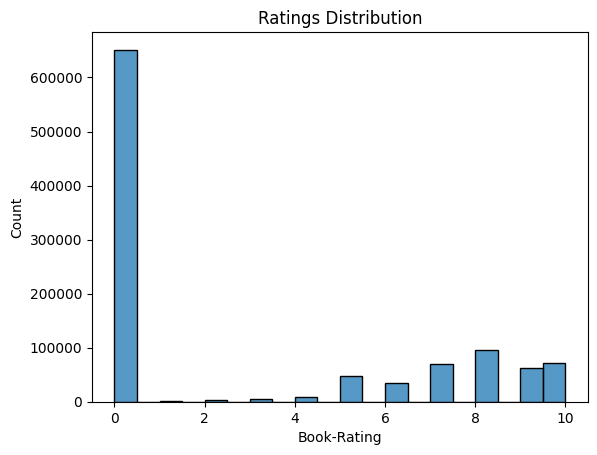

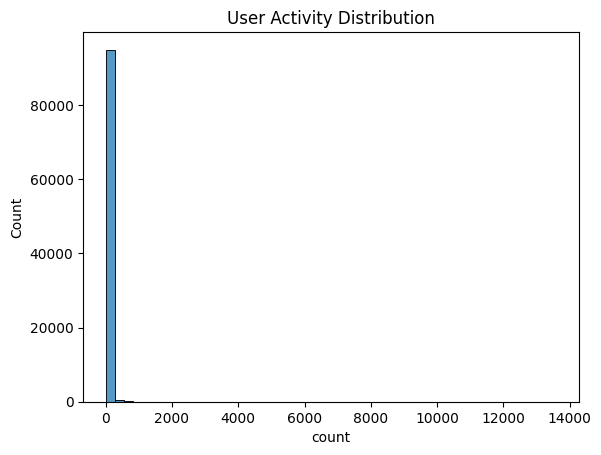

In [3]:
# Load datasets
books = pd.read_csv('../data/original/Books.csv')
users = pd.read_csv('../data/original/Users.csv')
ratings = pd.read_csv('../data/original/Ratings.csv')

# Display basic info
print('Books:', books.shape)
print('Users:', users.shape)
print('Ratings:', ratings.shape)

# Visualize ratings distribution
sns.histplot(ratings['Book-Rating'], bins=20)
plt.title('Ratings Distribution')
plt.show()

# Visualize user activity
user_activity = ratings['User-ID'].value_counts()
sns.histplot(user_activity, bins=50)
plt.title('User Activity Distribution')
plt.show()

## 2. Load and Explore the Dataset
Load the book ratings and metadata, and visualize key statistics.

In [2]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Recommendation models
import torch

from libreco.algorithms import NCF
from libreco.evaluation import evaluate
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV
# Add other imports as needed for GNN and hybrid models


Instructions for updating:
non-resource variables are not supported in the long term


## 1. Import Required Libraries
Import libraries for data manipulation, visualization, and recommendation models.

# Unified Book Recommendation System

This notebook builds and optimizes a book recommender system using collaborative filtering, neural models, and graph-based approaches. The goal is to achieve the best possible accuracy using multiple evaluation metrics.

In [1]:
print(1)

1
